In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

In [2]:
df_ = pd.read_csv('mgen_runtimes.tsv', sep='\t')
df_

,name,pool_size,runtime_sec
0,pairs_0092129,342,54.58
1,pairs_014a5c7,324,23.88
2,pairs_01b3c2c,351,30.29
3,pairs_0270315,376,27.92
4,pairs_0276a10,318,23.85
...,...,...,...
18384,pools_4k_d570bba,4046,1753.65
18385,pools_4k_d6de23e,4045,1780.34
18386,pools_5k_65d96bc,5014,3040.08
18387,pools_5k_b77b968,5013,2970.88


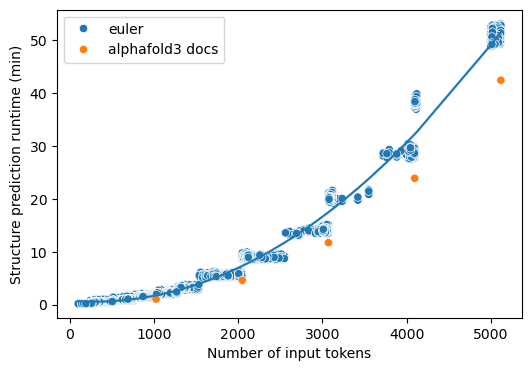

In [3]:
predict_runtime = np.poly1d(np.polyfit(x=df_.pool_size, y=df_.runtime_sec, deg=2))
# https://github.com/google-deepmind/alphafold3/blob/main/docs/performance.md
data_ref_ = pd.DataFrame.from_records([(1024, 62), (2048, 275), (3072, 703), (4096, 1434), (5120, 2547)], columns=['pool_size', 'runtime_sec'])
data_ = pd.concat([
    df_[['pool_size', 'runtime_sec']].assign(source='euler'),
    data_ref_.assign(source='alphafold3 docs'),
], axis=0)

plt.figure(figsize=(6, 4))
sns.scatterplot(data_, x='pool_size', y='runtime_sec', hue='source')
sns.lineplot(x=df_.pool_size, y=predict_runtime(df_.pool_size))
yticks_min = [0, 10, 20, 30, 40, 50]
plt.gca().set_yticks(60 * np.array(yticks_min), labels=yticks_min)
plt.gca().set_xlabel('Number of input tokens')
plt.gca().set_ylabel('Structure prediction runtime (min)')
plt.savefig('mgen_runtimes.svg', bbox_inches='tight', transparent=True)